# PHSX 256 Topic 11: Difference Equations

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# Use a modern, explicit RNG for reproducibility
rng = np.random.default_rng(42)


Matplotlib is building the font cache; this may take a moment.


## Difference Equations at a Glance

A **difference equation** advances a state $x_n$ to $x_{n+1}$ using a rule $x_{n+1} = f(x_n, x_{n-1}, \ldots)$, possibly with parameters or additional state variables. Examples include:

- Deterministic update: $N_{n+1} = r\,N_n$.
- Stochastic update: $x_{n+1} = x_n + s_n$ where $s_n$ is a random step.
- Multi-variable update: $\mathbf{x}_{n+1} = F(\mathbf{x}_n)$.

In physics, many systems are *naturally discrete*: particle hops on a lattice, counts of quanta or events, turn-based interactions, queueing of packets or photons, etc.

**Background**

Difference equations model systems that evolve in discrete steps: generations, turns, ticks, or collisions. They are not merely numerical approximations to differential equations; many physical processes are intrinsically stepwise. Key qualitative questions mirror those asked of continuous systems: fixed points, stability, oscillations, and sensitivity.

**Mathematical approach**

A typical scalar map is $x_{n+1} = f(x_n)$; a vector map is $\mathbf{x}_{n+1} = F(\mathbf{x}_n)$. 

A **fixed point** $x^*$ satisfies $x^* = f(x^*)$. Linear stability near a fixed point follows from the slope: if $|f'(x^*)|<1$, small perturbations decay; if $|f'(x^*)|>1$, they grow. In multi-variable settings, the Jacobian $J = \partial F/\partial \mathbf{x}$ at the fixed point governs stability via its eigenvalues.

**Significant results**

Discrete systems can exhibit period-doubling, intermittency, and chaos—even with simple rules. Cobweb diagrams, time-series plots, and parameter scans are powerful visual tools to understand these behaviors.


## One-Dimensional Random Walk (Discrete Hopping)

**Model**: At each step, move left or right by one unit with equal probability.

$x_{n+1} = x_n + s_n$ where $s_n \in \{-1, +1\}$

**Notes**
- Ensemble averages for unbiased steps:
- $\mathbb{E}[x_n] = 0$
- $\mathrm{Var}(x_n) = n$ 

**Background**

The unbiased random walk models a particle hopping left/right with equal probability—an archetype for diffusion and noise. By the central limit theorem, the distribution of positions tends to a Gaussian as steps grow.

**Mathematical approach**

Let $x_0=0$ and $x_{n+1}=x_n+s_n$ with $s_n\in\{-1,+1\}$ and $\mathbb{E}[s_n]=0$. Then $\mathbb{E}[x_n]=0$ and $\mathrm{Var}(x_n)=n$. Ensemble simulation uses vectorized cumulative sums; histograms at fixed $n$ approximate the Gaussian bell.

**Significant results**

- The **standard deviation** grows as $\sqrt{n}$.
- Trajectories wander but remain centered near zero; rare excursions scale with $\sqrt{n}$.


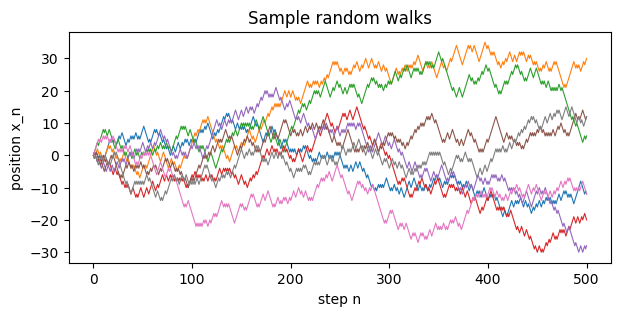

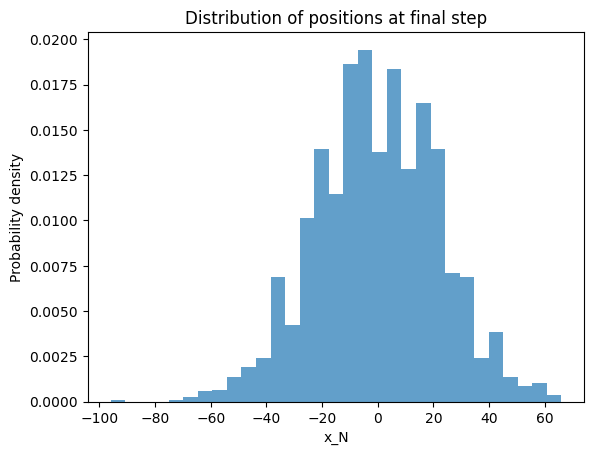

Empirical mean ~ -0.164
Empirical variance ~ 493.677104


In [3]:

# Parameters
steps = 500
walkers = 2000

steps_array = rng.choice([-1, 1], size=(walkers, steps))
X = np.cumsum(steps_array, axis=1)
X = np.hstack([np.zeros((walkers,1)), X])  # include x_0=0

# Plot a few sample paths
plt.figure(figsize=(7,3))
for k in range(8):
    plt.plot(X[k, :], lw=0.8)
plt.xlabel('step n')
plt.ylabel('position x_n')
plt.title('Sample random walks')
plt.show()

# Histogram at final time and compare mean/variance
final_positions = X[:, -1]
plt.figure()
plt.hist(final_positions, bins=31, density=True, alpha=0.7)
plt.xlabel('x_N')
plt.ylabel('Probability density')
plt.title('Distribution of positions at final step')
plt.show()

print('Empirical mean ~', np.mean(final_positions))
print('Empirical variance ~', np.var(final_positions))


## Exponential Growth/Decay (Deterministic)

**Model**: Over each step (generation), the count changes by a fixed factor $r$.

$N_{n+1} = r\,N_n$

**Notes**
- If $r>1$, growth.
- If $0<r<1$, decay.

**Background**

This is the canonical bookkeeping model of reproduction or multiplicative change per step—e.g., a chain reaction where each particle spawns a factor $r$ of the previous count. It is also a baseline for calibration and sanity checks in simulations.

**Mathematical approach**

Iterating $N_{n+1} = r\,N_n$ yields the closed form $N_n = N_0 r^n$. The unique fixed point is $N^*=0$ (all $N$ are fixed only if $r=1$). Stability of $N^*=0$ follows from $|r|<1$. For $r>1$, trajectories grow without bound (in the absence of saturation). A log transform linearizes the relation: $\ln N_n = \ln N_0 + n\,\ln r$, so the slope in a semi-log plot estimates $\ln r$.

**Significant results**

- **Doubling time** (for $r>1$): $n_d = \dfrac{\ln 2}{\ln r}$.- **Half-life in steps** (for $0<r<1$): $n_{1/2} = \dfrac{\ln(1/2)}{\ln r}$.- Sensitivity: small errors in $r$ compound geometrically with $n$.


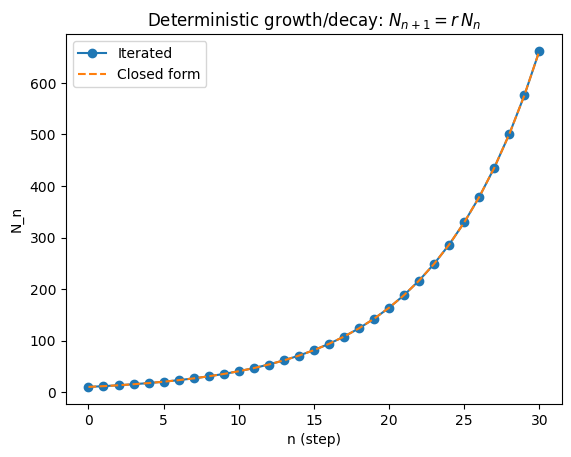

In [4]:

# Parameters
N0 = 10.0
r = 1.15
steps = 30

# Simulation
N = np.empty(steps+1)
N[0] = N0
for n in range(steps):
    N[n+1] = r * N[n]

# Closed form for comparison: N_n = N0 * r**n
n = np.arange(steps+1)
N_closed = N0 * (r ** n)

# Plot
plt.figure()
plt.plot(n, N, 'o-', label='Iterated')
plt.plot(n, N_closed, '--', label='Closed form')
plt.xlabel('n (step)')
plt.ylabel('N_n')
plt.title('Deterministic growth/decay: $N_{n+1} = r\\,N_n$')
plt.legend()
plt.show()


## Logistic-Type Discrete Regulation (Saturation by Capacity)

**Model**: Growth limited by carrying capacity $K$.

$N_{n+1} = r\,N_n\left(1 - \dfrac{N_n}{K}\right)$

**Notes**
- Explore fixed points and transitions to oscillations as $r$ increases.
- Use cobweb plots or time series to visualize dynamics.

**Background**

Resource-limited growth introduces a carrying capacity $K$, preventing unbounded increase. In discrete time, the logistic rule can generate oscillations and chaos depending on $r$, highlighting how discreteness changes qualitative behavior.

**Mathematical approach**

- Normalize $x_n = N_n/K$ to get $x_{n+1} = r x_n (1 - x_n)$.
- Fixed points are $x^*=0$ and $x^* = 1 - 1/r$ (the latter exists for $r>1$).
- Local stability: $f'(x) = r(1 - 2x)$, so $x^*=0$ is stable for $|r|<1$, and $x^* = 1 - 1/r$ is stable when $|2 - r| < 1$ (i.e., $1<r<3$).
- As $r$ increases beyond $3$, period-doubling cascades appear, and for larger $r$ the map exhibits chaos.
- Cobweb diagrams visualize attraction or divergence around fixed points/periodic orbits.

**Significant results**

- Demonstrates period-doubling route to chaos in a physics-friendly setting.- Sensitivity to initial conditions emerges in the chaotic regime.- Practical caution: if $N_n$ models counts, you may clip to nonnegative and/or use integers to maintain realism.


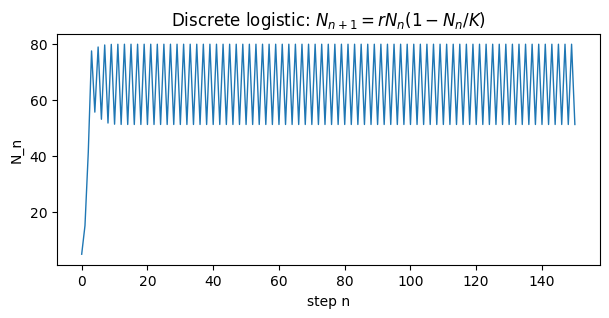

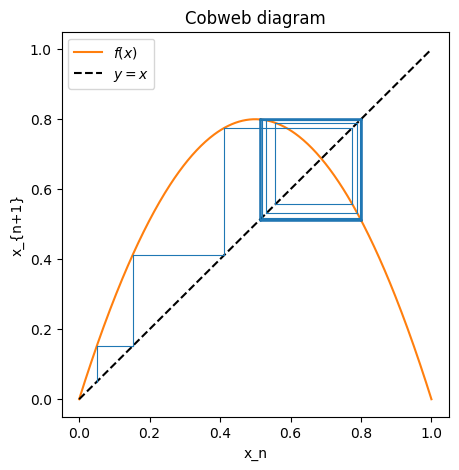

In [5]:

# Parameters
K = 100.0
r = 3.2
N0 = 5.0
steps = 150

# Simulation
N = np.empty(steps+1)
N[0] = N0
for n in range(steps):
    N[n+1] = r * N[n] * (1 - N[n]/K)

# Plot time series
plt.figure(figsize=(7, 3))
plt.plot(N, '-', lw=1)
plt.xlabel('step n')
plt.ylabel('N_n')
plt.title('Discrete logistic: $N_{n+1}= r N_n (1 - N_n/K)$')
plt.show()

# Optional: cobweb against normalized x = N/K
x = N / K
f = lambda x: r * x * (1 - x)
xs = np.linspace(0, 1, 400)

plt.figure(figsize=(5,5))
plt.plot(xs, f(xs), 'C1', label='$f(x)$')
plt.plot(xs, xs, 'k--', label='$y=x$')
# Cobweb starting from x0
x0 = N0 / K
xn = x0
iters = 60
for _ in range(iters):
    yn = f(xn)
    plt.plot([xn, xn], [xn, yn], 'C0', lw=0.8)
    plt.plot([xn, yn], [yn, yn], 'C0', lw=0.8)
    xn = yn
plt.xlabel('x_n')
plt.ylabel('x_{n+1}')
plt.title('Cobweb diagram')
plt.legend()
plt.show()


**Bifurcation diagram (normalized logistic map)**

We complement the time series and cobweb plot with a classic **bifurcation diagram** for the normalized logistic map $x_{n+1} = r x_n (1 - x_n)$ on $[0,1]$. For each parameter value $r \in [0,4]$, we iterate from an initial $x_0$ for many steps, discard transients, and plot the long-term values of $x_n$.

**What to look for**

- For $0<r<1$, the only attractor is $x=0$.
- For $1<r<3$, the nonzero fixed point $x^* = 1 - 1/r$ is stable.
- Near $r=3$, a **period-doubling cascade** begins (period-2, 4, 8, ...) leading to **chaos** as $r$ approaches $\approx 3.56995\,\dots$ (the Feigenbaum point).
- Inside the chaotic region, **periodic windows** (e.g., period-3) appear amid the chaos.


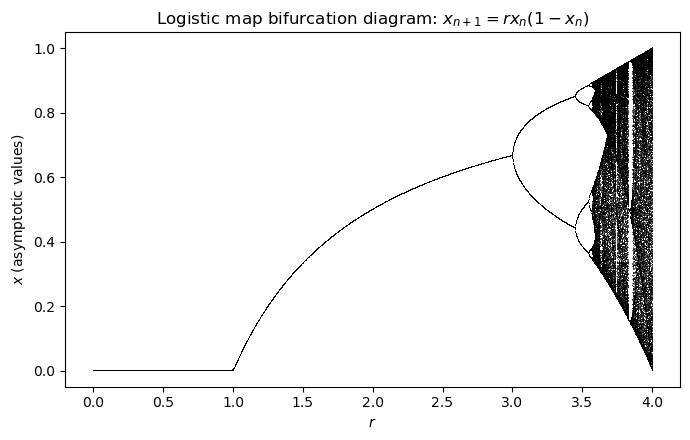

In [6]:

# Bifurcation diagram for the logistic map x_{n+1} = r x_n (1 - x_n)
r_vals = np.linspace(0.0, 4.0, 3000)
n_transient = 500
n_keep = 200
x0 = 0.37

rs = []
xs = []
for r in r_vals:
    x = x0
    for n in range(n_transient + n_keep):
        x = r * x * (1 - x)
        if n >= n_transient:
            rs.append(r)
            xs.append(x)

plt.figure(figsize=(7, 4.5))
plt.plot(rs, xs, ',k', alpha=0.6)
plt.xlabel('$r$')
plt.ylabel('$x$ (asymptotic values)')
plt.title('Logistic map bifurcation diagram: $x_{n+1}= r x_n (1 - x_n)$')
plt.tight_layout()
plt.show()


## Predator–Prey Bookkeeping (Discrete Interactions)

**Model**: Update prey $H$ and predators $P$ each step using simple interaction rules.

$\begin{aligned}
H_{n+1} &= H_n + a H_n - b H_n P_n \\
P_{n+1} &= P_n - c P_n + d H_n P_n
\end{aligned}$

**Notes**
- Treat $a,b,c,d$ as per-step rates of birth, predation, death, and conversion.
- This is a *discrete* interaction picture rather than a discretized ODE.

**Background**

This stepwise interaction model mirrors per-step births, deaths, and encounters between prey $H$ and predators $P$. Unlike continuous Lotka–Volterra equations, we emphasize discrete bookkeeping over each interval, better matching coarse-grained sampling.

**Mathematical approach**

Set $H_{n+1}=H_n$ and $P_{n+1}=P_n$ to locate fixed points. Besides $(0,0)$, a coexistence fixed point arises from $a - bP^* = 0$ and $-c + dH^* = 0$, so $P^* = a/b$ and $H^* = c/d$. Linearizing the 2D map around $(H^*,P^*)$ with the Jacobian matrix provides local stability (eigenvalues inside the unit circle imply stability).

**Significant results**

- Depending on parameters, you may observe damped oscillations toward coexistence, sustained cycles, or crashes (extinction).
- Nonnegativity constraints are important; clip negative updates or tune parameters to avoid unphysical states.


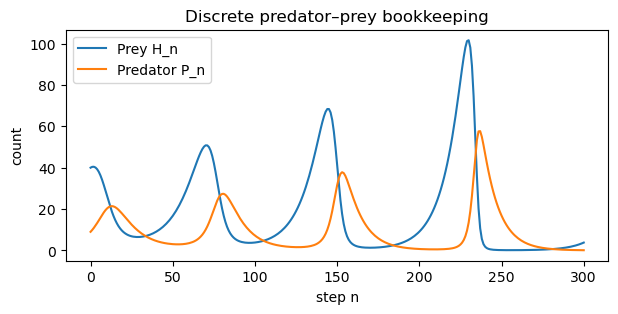

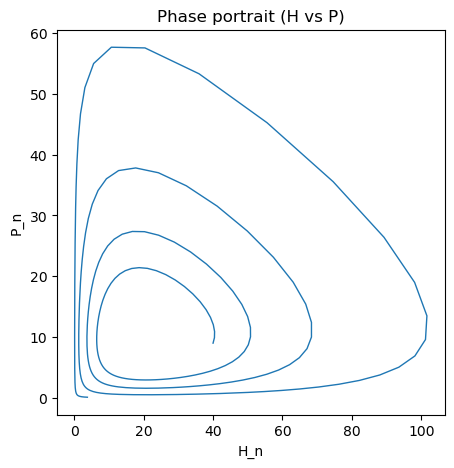

In [7]:

# Parameters
H0, P0 = 40.0, 9.0
a, b, c, d = 0.10, 0.01, 0.10, 0.005
steps = 300

H = np.empty(steps+1)
P = np.empty(steps+1)
H[0], P[0] = H0, P0

for n in range(steps):
    H[n+1] = H[n] + a*H[n] - b*H[n]*P[n]
    P[n+1] = P[n] - c*P[n] + d*H[n]*P[n]

plt.figure(figsize=(7,3))
plt.plot(H, label='Prey H_n')
plt.plot(P, label='Predator P_n')
plt.xlabel('step n')
plt.ylabel('count')
plt.title('Discrete predator–prey bookkeeping')
plt.legend()
plt.show()

# Phase portrait
plt.figure(figsize=(5,5))
plt.plot(H, P, '-', lw=1)
plt.xlabel('H_n')
plt.ylabel('P_n')
plt.title('Phase portrait (H vs P)')
plt.show()


## Gambler's Ruin / First-Passage to Absorbing Boundaries

**Model**: Position executes a random walk on integers with absorbing boundaries at $0$ and $W$.

**Goal**: Record the time to absorption and the probability of reaching $W$ starting from $x_0$.

**Background**

First-passage problems appear in physics (e.g., reaction times, escape events). The gambler’s ruin is a discrete prototype with absorbing boundaries at $0$ and $W$.

**Mathematical approach**

For a fair walk, the probability of eventually hitting $W$ before $0$ starting from $x_0$ is $x_0/W$. The expected absorption time scales like $x_0(W-x_0)$ (up to constants). Simulation estimates these by repeated trials with a stopping condition.

**Significant results**

- **Absorption is certain** in 1D for an unbiased walk.
- Distributions of absorption times are broad and skewed; medians are typically much smaller than maxima.


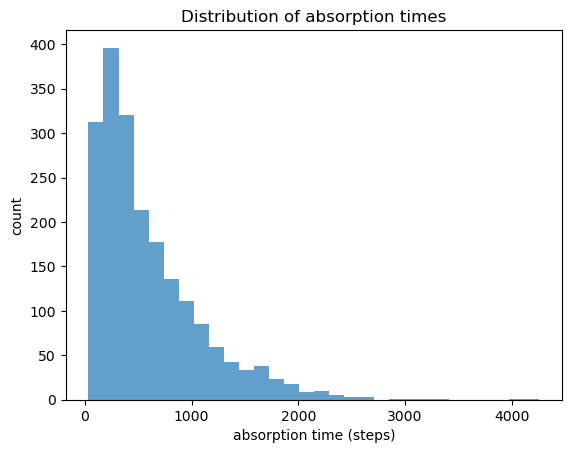

Empirical P(reach W) ~ 0.3995
,Mean absorption time ~ 599.747


In [8]:

# Parameters
W = 50
x0 = 20
trials = 2000

hit_W = 0
T = []
for _ in range(trials):
    x = x0
    t = 0
    while 0 < x < W:
        step = rng.choice([-1, 1])
        x += step
        t += 1
    hit_W += int(x == W)
    T.append(t)

plt.figure()
plt.hist(T, bins=30, alpha=0.7)
plt.xlabel('absorption time (steps)')
plt.ylabel('count')
plt.title('Distribution of absorption times')
plt.show()

print('Empirical P(reach W) ~', hit_W / trials)
print('Mean absorption time ~', np.mean(T))


## Radioactive Decay as Event Counting (Binomial Thinning)

**Model**: Each of $N_n$ nuclei survives to the next step with probability $1-p$, independently.

$N_{n+1} = N_n - X_n$ where $X_n \sim \mathrm{Binomial}(N_n, p)$

**Notes**
- Emphasizes stochasticity around an exponential trend.
- Compare ensemble average to a deterministic curve.

**Background**

Radioactive decay can be modeled as independent trials per nucleus each step with success probability $p$ of decaying. This is a discrete-time view of a Poisson process.

**Mathematical approach**

Conditional on $N_n$, the number of decays $X_n$ is binomial: $X_n\sim\mathrm{Binomial}(N_n,p)$. The mean evolves as $\mathbb{E}[N_{n+1}] = (1-p)\,\mathbb{E}[N_n]$, giving $\mathbb{E}[N_n]=N_0(1-p)^n$. From the curve, you can estimate $p$ via a semi-log fit. The **half-life in steps** is $n_{1/2} = \dfrac{\ln 2}{\ln(1/(1-p))}$.

**Significant results**

- Sample paths fluctuate around the mean exponential trend.
- Variability is largest when counts are moderate and shrinks as the population dwindles.


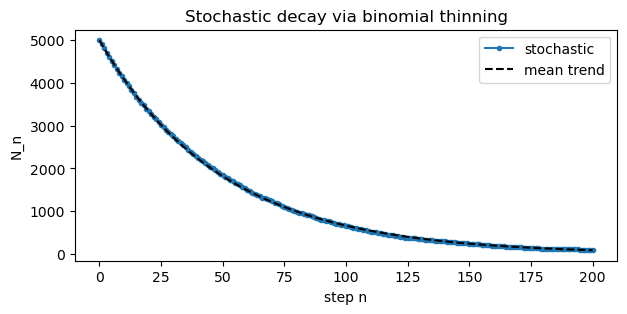

In [9]:

# Parameters
N0 = 5000
p = 0.02  # per-step decay probability
steps = 200

N = np.empty(steps+1, dtype=int)
N[0] = N0
for n in range(steps):
    decays = rng.binomial(N[n], p)
    N[n+1] = N[n] - decays

# Deterministic expectation: E[N_n] = N0 * (1-p)**n
n = np.arange(steps+1)
E = N0 * ((1 - p) ** n)

plt.figure(figsize=(7,3))
plt.plot(n, N, 'o-', ms=3, label='stochastic')
plt.plot(n, E, 'k--', label='mean trend')
plt.xlabel('step n')
plt.ylabel('N_n')
plt.title('Stochastic decay via binomial thinning')
plt.legend()
plt.show()


## Cellular Automaton (1D): Rule 30

**Model**: A binary string updates by local rules. Rule 30 is a classic example producing complex patterns from simple rules.

**Local update** (neighborhood to next-state mapping) summarized by Wolfram code 30.

**Background**

Rule 30 is a simple 1D cellular automaton that exhibits complex, seemingly random patterns from deterministic local rules. It’s a classic demonstration of emergence from local interactions.

**Mathematical approach**

Each cell updates from the triplet $(l,c,r)$ using a fixed lookup table (Wolfram code 30). Using periodic boundary conditions simplifies the implementation. The space–time diagram visualizes evolution: time downward and space horizontally.

**Significant results**

- Left-hand side appears statistically random; right side shows a Sierpinski-like triangular structure.
- Serves as a bridge to discrete pattern formation and pseudo-randomness.


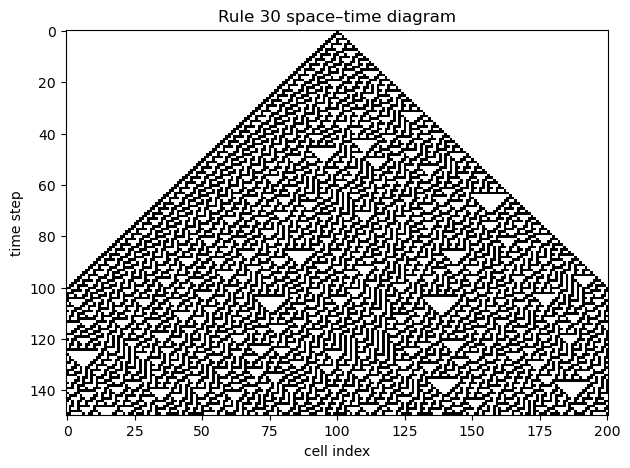

In [10]:

# Rule 30 implementation
# Neighborhood (l, c, r) -> new state according to rule 30
rule_num = 30
rule_bits = np.array([(rule_num >> i) & 1 for i in range(8)], dtype=int)  # from 0..7

# Map neighborhood (l,c,r) as 3-bit index  (l<<2)|(c<<1)|r, with 111 -> index 7, ..., 000 -> index 0

def rule30_step(state):
    L = state.size
    left = np.roll(state, 1)
    right = np.roll(state, -1)
    idx = (left << 2) | (state << 1) | right
    return rule_bits[idx]

# Initialize with a single 1 centered
L = 201
steps = 150
state = np.zeros(L, dtype=int)
state[L//2] = 1

history = np.zeros((steps, L), dtype=int)
for n in range(steps):
    history[n] = state
    state = rule30_step(state)

# Visualize space-time diagram
plt.figure(figsize=(7,5))
plt.imshow(history, cmap='binary', interpolation='nearest', aspect='auto')
plt.xlabel('cell index')
plt.ylabel('time step')
plt.title('Rule 30 space–time diagram')
plt.show()


## Ising-Like Spin Update (1D Majority Rule)

**Model**: Spins $s_i^{(n)} \in \{-1, +1\}$ update by the sign of neighbor sum.

$s_i^{(n+1)} = \mathrm{sign}\!\left(s_{i-1}^{(n)} + s_{i+1}^{(n)}\right)$ (ties keep the current state)

**Notes**
- Demonstrates local interactions and domain coarsening without invoking thermal noise.

**Background**

This is a zero-temperature, deterministic analogue of spin alignment: spins prefer to align with their neighbors (majority wins). It demonstrates domain coarsening and metastability without invoking thermal noise.

**Mathematical approach**

Update by $s_i^{(n+1)} = \mathrm{sign}(s_{i-1}^{(n)} + s_{i+1}^{(n)})$; on ties, keep the current spin. Domain walls (interfaces between $+1$ and $-1$) tend to annihilate, increasing typical domain sizes over time.

**Significant results**

- Coarsening leads toward uniform states (all $+1$ or all $-1$) on finite rings, though long-lived patterns may persist.
- Space–time plots reveal merging and straightening of domain boundaries.


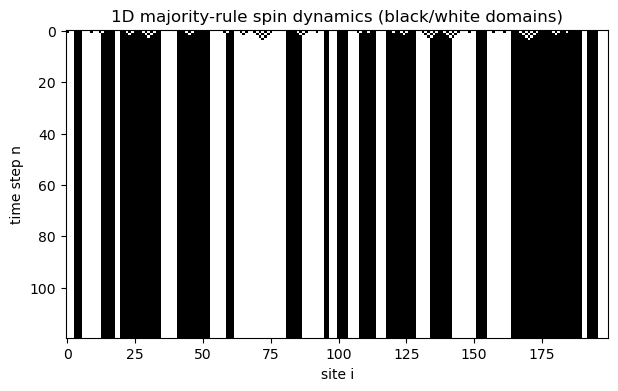

In [11]:

# Majority-rule dynamics on a ring
L = 200
steps = 120
spins = rng.choice([-1, 1], size=L)

history = np.zeros((steps, L), dtype=int)
for n in range(steps):
    history[n] = spins
    left = np.roll(spins, 1)
    right = np.roll(spins, -1)
    s = left + right
    update = np.where(s > 0, 1, np.where(s < 0, -1, spins))
    spins = update

plt.figure(figsize=(7,4))
plt.imshow((history+1)/2, cmap='gray', interpolation='nearest', aspect='auto')
plt.xlabel('site i')
plt.ylabel('time step n')
plt.title('1D majority-rule spin dynamics (black/white domains)')
plt.show()


## Traffic Flow on a Ring (Exclusion Rule)

**Model**: A 1D ring road with binary occupancy; each car attempts to move one cell forward if that cell is empty.

Update is discrete and respects exclusion (no two cars in the same cell).

**Background**

This exclusion process models cars on a single-lane ring: each car advances if the next site is empty. It captures essential features of traffic like jams and a fundamental flow–density relation.

**Mathematical approach**

In random sequential TASEP on a ring, the steady-state current (flow per site per step) scales as $J = \rho(1-\rho)$, where $\rho$ is car density. Simulation measures total moves per step and compares with this prediction.

**Significant results**

- Space–time diagrams show diagonal streaks (moving cars) and horizontal bands (jams).
- Maximal flow near $\rho=1/2$; low flow at very low or very high densities.


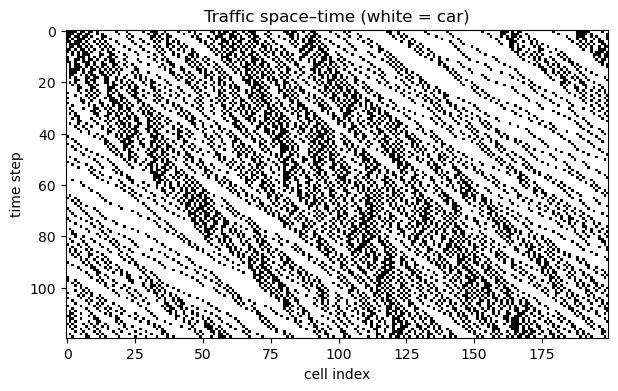

Average moves per step ~ 83.63


In [12]:

L = 200           # number of cells on ring
rho = 0.3         # density of cars
steps = 300

# Initialize occupancy
occ = np.zeros(L, dtype=int)
occ[rng.choice(L, size=int(rho*L), replace=False)] = 1

flow_count = 0
hist = np.zeros((steps, L), dtype=int)

for n in range(steps):
    hist[n] = occ
    # Random sequential update: visit sites in random order
    order = rng.permutation(L)
    for i in order:
        if occ[i] == 1 and occ[(i+1) % L] == 0:
            occ[i] = 0
            occ[(i+1) % L] = 1
            flow_count += 1

avg_flow = flow_count / steps  # cars per step (summed moves per step)

plt.figure(figsize=(7,4))
plt.imshow(hist[:120], cmap='binary', interpolation='nearest', aspect='auto')
plt.xlabel('cell index')
plt.ylabel('time step')
plt.title('Traffic space–time (white = car)')
plt.show()

print('Average moves per step ~', avg_flow)


## Energy/Resource Accounting (Budget Model)

**Model**: Track a resource with discrete gains and losses per step.

$E_{n+1} = E_n + \Delta E_{\text{in}} - \Delta E_{\text{out}}$

**Example**: A battery experiences random charge/discharge events per time step.

**Background**

Many systems are governed by discrete conservation and exchange: stored energy, charge packets, or inventory units. This model tracks a resource under random inputs and outputs per step with a reflecting floor at zero.

**Mathematical approach**

Write $E_{n+1} = E_n + \Delta E_{\text{in}} - \Delta E_{\text{out}}$. If the mean outflow exceeds inflow, the process drifts toward the floor; if inflow exceeds outflow, it drifts upward; near balance, it fluctuates around a stochastic equilibrium.

**Significant results**

- Long spells at the floor occur when outflow dominates (resource depletion).
- Variability depends on packet statistics (e.g., Poisson variance equals its mean).


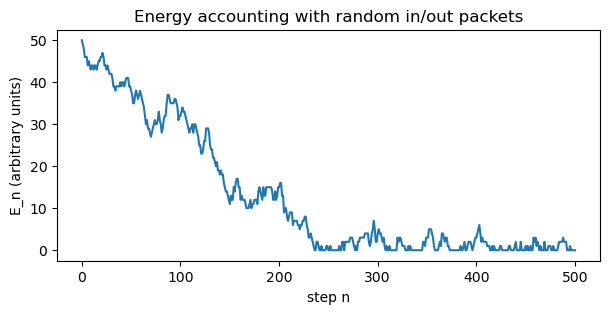

In [13]:

steps = 500
E = np.empty(steps+1)
E[0] = 50.0

# Random in/out packets per step
for n in range(steps):
    Ein = rng.poisson(0.8) * 1.0   # units in
    Eout = rng.poisson(1.0) * 1.0  # units out
    E[n+1] = max(0.0, E[n] + Ein - Eout)  # floor at 0

plt.figure(figsize=(7,3))
plt.plot(E, '-')
plt.xlabel('step n')
plt.ylabel('E_n (arbitrary units)')
plt.title('Energy accounting with random in/out packets')
plt.show()


## Kinetic Exchange (Wealth/Energy Redistribution)

**Model**: $N$ agents exchange one unit at a time at random; no agent can go negative.

**Question**: What does the steady-state distribution look like?

**Background**

Simple exchange models conserve total units while randomly transferring them between agents, mirroring energy exchanges in gases (Boltzmann picture) or idealized wealth exchanges.

**Mathematical approach**

Randomly select a donor/receiver each step; if the donor has $>0$ units, move one unit. The state forms a Markov chain with conserved total units. The stationary distribution tends to be approximately exponential (Boltzmann–Gibbs-like) for this minimal rule.

**Significant results**

- The histogram of holdings is close to $P(k) \propto e^{-k/\bar{k}}$ with mean $\bar{k}$ conserved.
- Micro-level randomness plus conservation yields a universal-looking macro distribution.


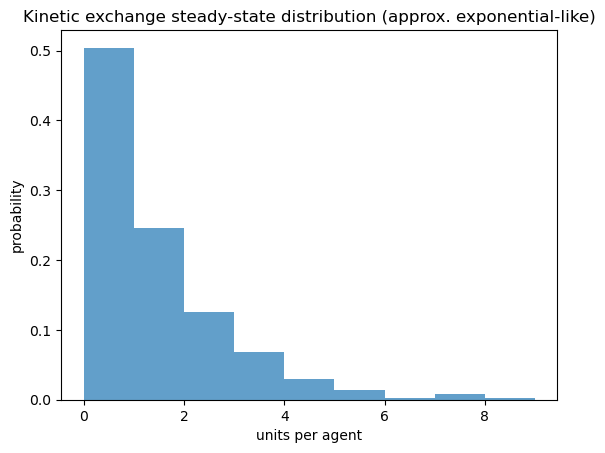

Mean units per agent: 0.976


In [14]:

N_agents = 500
units = 2000
steps = 200_000

# Initialize all units randomly among agents
wallets = np.zeros(N_agents, dtype=int)
wallets[rng.integers(0, N_agents, size=units)] += 1

for _ in range(steps):
    i, j = rng.integers(0, N_agents, size=2)
    if wallets[i] > 0:
        wallets[i] -= 1
        wallets[j] += 1

plt.figure()
plt.hist(wallets, bins=range(0, np.max(wallets)+2), density=True, alpha=0.7)
plt.xlabel('units per agent')
plt.ylabel('probability')
plt.title('Kinetic exchange steady-state distribution (approx. exponential-like)')
plt.show()

print('Mean units per agent:', wallets.mean())


## Piecewise Map: Tent Map

**Model**: The tent map on $[0,1]$ with parameter $\mu$.

$x_{n+1} = \begin{cases}
\mu x_n & \text{if } x_n < 1/2 \\
\mu (1 - x_n) & \text{if } x_n \ge 1/2
\end{cases}$

**Notes**
- Simple to implement and rich in behavior as $\mu$ varies.

**Background**

The tent map is a classic piecewise-linear chaotic map on $[0,1]$. Despite its simplicity, it displays sensitive dependence on initial conditions and rich parameter-dependent behavior.

**Mathematical approach**

For parameter $\mu$, define $x_{n+1} = \mu x_n$ if $x_n<1/2$ and $x_{n+1} = \mu(1-x_n)$ otherwise. For $\mu=2$, the Lyapunov exponent is $\ln 2$ (strong chaos). Parameter scans reveal fixed points/periodic windows vs chaotic bands.

**Significant results**

- As $\mu$ increases beyond $1$, trajectories typically lose stability and become chaotic.
- The bifurcation-like scatter plot summarizes long-term values as parameters vary.


<>:35: SyntaxWarning: invalid escape sequence '\m'
,<>:35: SyntaxWarning: invalid escape sequence '\m'
,/tmp/ipykernel_1755779/3380904393.py:35: SyntaxWarning: invalid escape sequence '\m'
,  plt.xlabel('$\mu$')


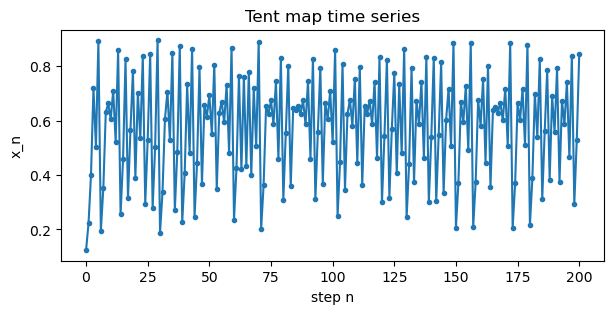

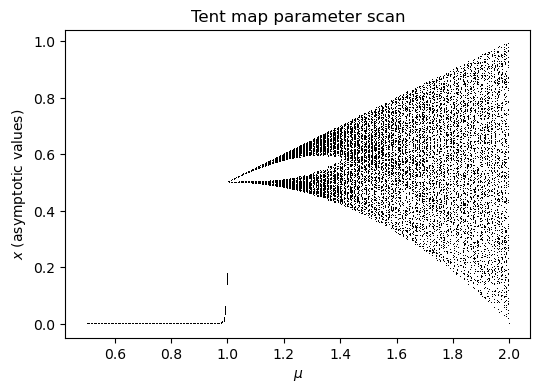

In [15]:

mu = 1.8
x0 = 0.1234
steps = 200

x = np.empty(steps+1)
x[0] = x0
for n in range(steps):
    if x[n] < 0.5:
        x[n+1] = mu * x[n]
    else:
        x[n+1] = mu * (1 - x[n])

plt.figure(figsize=(7,3))
plt.plot(x, '-o', ms=3)
plt.xlabel('step n')
plt.ylabel('x_n')
plt.title('Tent map time series')
plt.show()

# Parameter scan (bifurcation-like diagram)
mus = np.linspace(0.5, 2.0, 300)
keep = 80  # keep last points to approximate attractor
xn_out = []
mu_out = []
for mu in mus:
    x = 0.37
    for n in range(300):
        x = mu * x if x < 0.5 else mu * (1 - x)
        if n >= 300 - keep:
            xn_out.append(x)
            mu_out.append(mu)

plt.figure(figsize=(6,4))
plt.plot(mu_out, xn_out, ',k')
plt.xlabel('$\mu$')
plt.ylabel('$x$ (asymptotic values)')
plt.title('Tent map parameter scan')
plt.show()


## Queueing Dynamics (Arrivals and Departures)

**Model**: Queue length updates by

$N_{n+1} = N_n + A_n - D_n$

where $A_n$ are arrivals and $D_n$ are departures capped by available items and a service capacity.

**Background**

Queueing appears in detectors (counts), networks (packets), and service systems. Discrete-time queues accumulate random arrivals and are drained by a finite service capacity.

**Mathematical approach**

$N_{n+1} = N_n + A_n - D_n$, with $A_n$ random arrivals and $D_n$ limited by service capacity and current queue. When the mean arrival rate $\lambda$ is **below** capacity, the queue is stable in the long run; when above, it grows.

**Significant results**

- Time series reveal whether the system is stable (fluctuating around a finite level) or unstable (drifting upward).
- Heavy-tailed waiting times can emerge near the stability boundary.


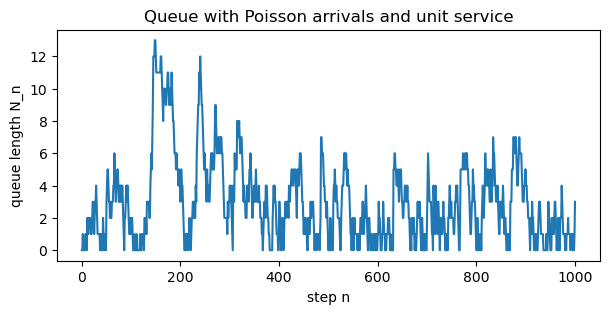

In [16]:

steps = 1000
lam = 0.9           # mean arrivals per step (Poisson)
capacity = 1        # max departures per step

N = np.zeros(steps+1, dtype=int)
for n in range(steps):
    arrivals = rng.poisson(lam)
    departures = min(N[n], capacity)
    N[n+1] = N[n] + arrivals - departures

plt.figure(figsize=(7,3))
plt.plot(N)
plt.xlabel('step n')
plt.ylabel('queue length N_n')
plt.title('Queue with Poisson arrivals and unit service')
plt.show()


## Discrete Diffusion via Hopping Rules

**Model**: Many particles perform independent unbiased random walks on a 1D lattice. Observe the spreading of the distribution.

**Expectation**: For independent walkers, $\mathrm{Var}(x_n) \propto n$.

**Background**

Many independent walkers performing simple random walks provide a microscopic model of diffusion without invoking PDEs.

**Mathematical approach**

With unbiased steps of variance $\sigma^2=1$, the distribution after $n$ steps is approximately Gaussian with variance $n\sigma^2$. Density profiles at increasing times broaden while staying normalized.

**Significant results**

- The variance grows linearly with steps: $\mathrm{Var}(x_n) \approx n$.
- Superimposed histograms across times visually confirm diffusive spreading.


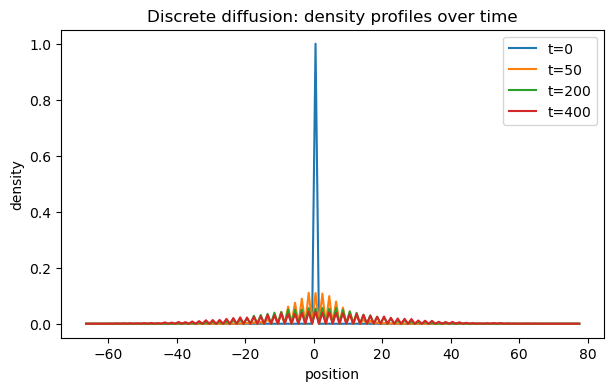

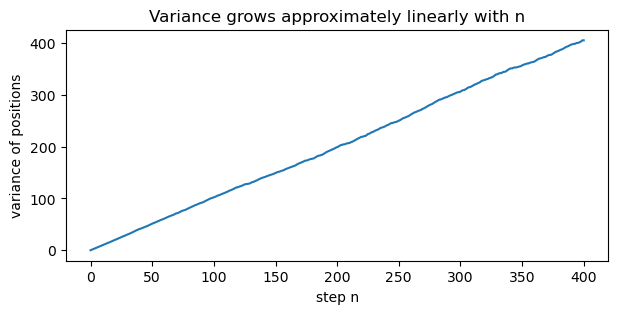

In [17]:

particles = 5000
steps = 400

steps_array = rng.choice([-1, 1], size=(particles, steps))
pos = np.cumsum(steps_array, axis=1)
pos = np.hstack([np.zeros((particles,1), dtype=int), pos])

# Density profile at several times
times = [0, 50, 200, 400]
plt.figure(figsize=(7,4))
for t in times:
    hist, edges = np.histogram(pos[:, t], bins=np.arange(pos.min()-1, pos.max()+2), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(centers, hist, label=f't={t}')
plt.xlabel('position')
plt.ylabel('density')
plt.title('Discrete diffusion: density profiles over time')
plt.legend()
plt.show()

# Variance growth
vars_ = pos.var(axis=0)
plt.figure(figsize=(7,3))
plt.plot(vars_)
plt.xlabel('step n')
plt.ylabel('variance of positions')
plt.title('Variance grows approximately linearly with n')
plt.show()


## Variations: Noise, Rounding, Thresholds, Delays

**Delayed feedback** example:

$x_{n+1} = a\,x_n\left(1 - x_{n-2}\right)$

**Threshold rule** example:

$x_{n+1} = \begin{cases}
\alpha x_n & \text{if } x_n < T \\
\beta x_n & \text{if } x_n \ge T
\end{cases}$

These patterns recur across discrete physical systems: delayed responses, hysteresis, and piecewise behaviors.

**Background**

Noise, thresholds, and delays are ubiquitous in real systems: sensors saturate, controls actuate only past thresholds, and responses are delayed. Discrete maps provide a compact lab to explore these effects.

**Mathematical approach**

A delayed map like $x_{n+1}=a\,x_n(1 - x_{n-2})$ effectively has a 2D state $(x_n, x_{n-1})$; stability is governed by the eigenvalues of the corresponding linearization. Threshold maps are piecewise linear, producing hysteresis and period-2 orbits.

**Significant results**

- Delays can induce oscillations even when instantaneous feedback would be stable.
- Piecewise rules create rich dynamics with simple code (switching behavior, multistability).


/tmp/ipykernel_1755779/4163496240.py:7: RuntimeWarning: overflow encountered in scalar multiply
,  x[n+1] = a * x[n] * (1 - x[n-1])


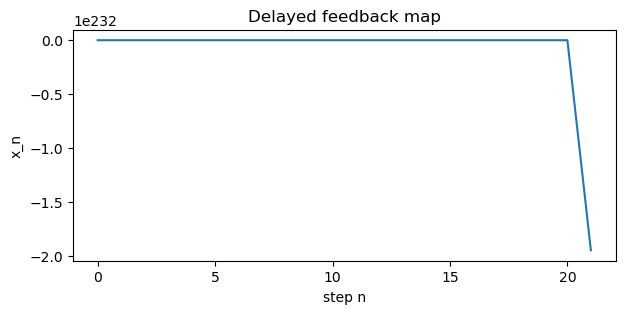

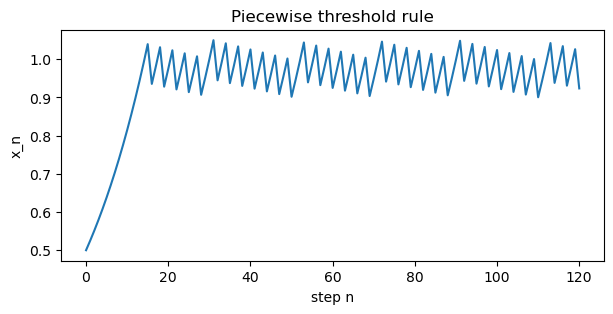

In [18]:

# Delayed feedback map
steps = 200
x = np.zeros(steps+1)
a = 2.4
x[0], x[1] = 0.1, 0.2
for n in range(1, steps):
    x[n+1] = a * x[n] * (1 - x[n-1])

plt.figure(figsize=(7,3))
plt.plot(x, '-')
plt.xlabel('step n')
plt.ylabel('x_n')
plt.title('Delayed feedback map')
plt.show()

# Threshold rule
alpha, beta, T = 1.05, 0.90, 1.0
steps = 120
x = np.empty(steps+1)
x[0] = 0.5
for n in range(steps):
    x[n+1] = (alpha * x[n]) if (x[n] < T) else (beta * x[n])

plt.figure(figsize=(7,3))
plt.plot(x, '-')
plt.xlabel('step n')
plt.ylabel('x_n')
plt.title('Piecewise threshold rule')
plt.show()
